In [3]:
#Import the required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# 1. Load IMDB Dataset

# Keep top 10,000 most frequent words
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))



17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training samples: 25000
Testing samples : 25000


In [7]:
# 2. Inspect one review
# -----------------------------------------------------------
word_index = keras.datasets.imdb.get_word_index()

# Reverse mapping
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

print("\nSample Review:\n")
print(decode_review(x_train[0]))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Sample Review:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole

In [25]:
# 3. Pad sequences (same length input)
# -----------------------------------------------------------
max_len = 256

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train,
    value=0,
    padding='post',
    maxlen=max_len)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test,
    value=0,
    padding='post',
    maxlen=max_len)



In [31]:
# 4. Build Deep Neural Network Model
# -----------------------------------------------------------
model = keras.Sequential([
    
    # Input layer (modern approach)
    layers.Input(shape=(max_len,)),
    
    # Convert word indexes to dense vectors
    layers.Embedding(vocab_size, 16),

    # Flatten output
    layers.GlobalAveragePooling1D(),

    # Hidden Deep Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer (Binary Classification)
    layers.Dense(1, activation='sigmoid')
])

In [33]:
# 5. Compile Model
# -----------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------------------------------------
# 6. Validation Split
# -----------------------------------------------------------
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 256, 16)             │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_7           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,201 (637.50 KB)

 Trainable params: 163,201 (637.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# 7. Train Model
# -----------------------------------------------------------
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=15,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

# -----------------------------------------------------------
# 8. Evaluate Model
# -----------------------------------------------------------
results = model.evaluate(x_test, y_test)

print("\nTest Loss     :", results[0])
print("Test Accuracy :", results[1] * 100, "%")


Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5183 - loss: 0.6925 - val_accuracy: 0.5895 - val_loss: 0.6901
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6267 - loss: 0.6829 - val_accuracy: 0.6388 - val_loss: 0.6726
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7191 - loss: 0.6309 - val_accuracy: 0.7727 - val_loss: 0.5782
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8012 - loss: 0.5034 - val_accuracy: 0.8343 - val_loss: 0.4263
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8305 - loss: 0.3998 - val_accuracy: 0.8473 - val_loss: 0.3683
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8597 - loss: 0.3414 - val_accuracy: 0.8666 - val_loss: 0.3300
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8917 - loss: 0.2875 - val_accuracy: 0.8370 - val_loss: 0.3546
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8999 - loss: 0.2615 - val_accuracy: 0.8694 - v

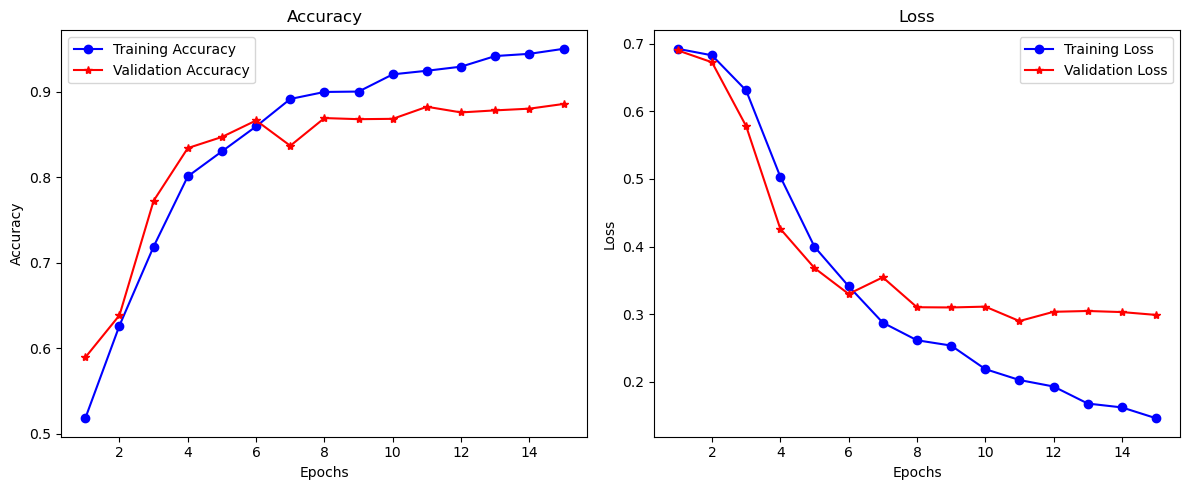

In [37]:
# 9. Plot Accuracy & Loss
# -----------------------------------------------------------
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [39]:
# 10. Predict New Review
# -----------------------------------------------------------
sample_review = x_test[0].reshape(1, max_len)

prediction = model.predict(sample_review)

print("\nPrediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

Prediction Score: 0.043671183
Negative Review 😞
